<a href="https://colab.research.google.com/github/evacragnolino/Data-Science-Foundations/blob/main/Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

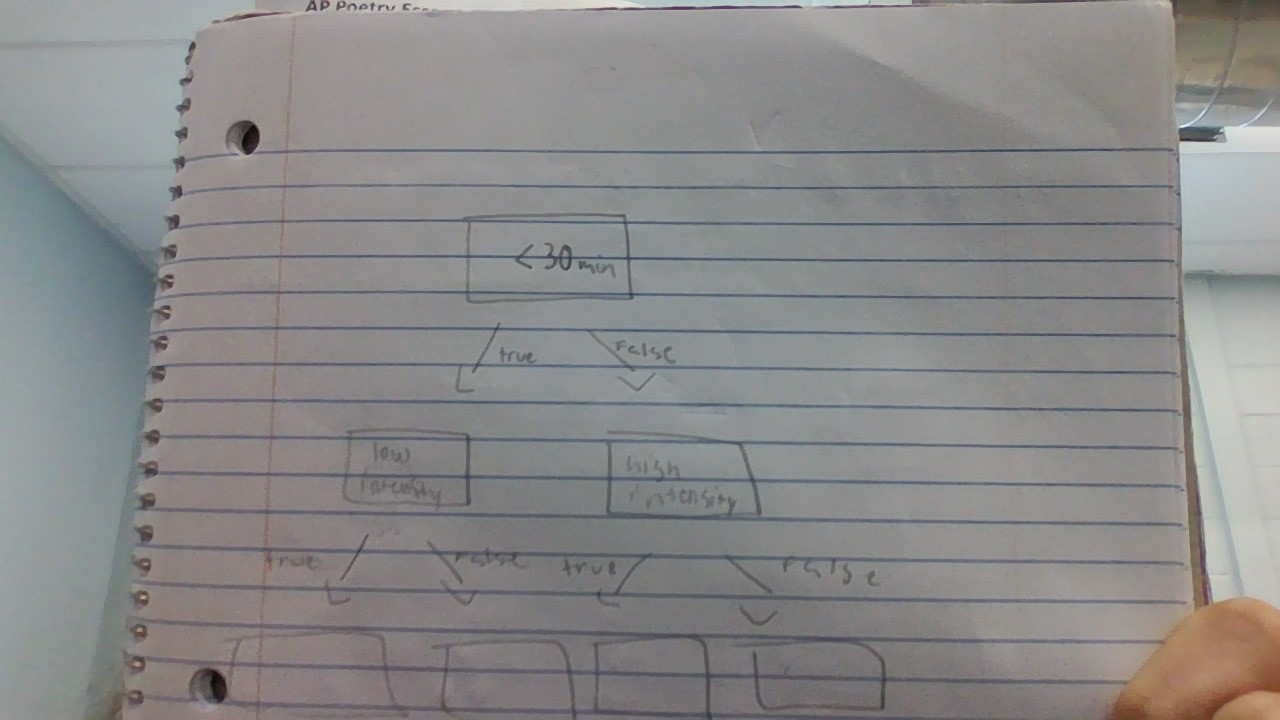

**Task2**:

What is a decision tree? How do they work?

they are flow charts that start with one parent node and many children and they are binary. The tree sorts into predicted value.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

the amount of parent nodes.

**Task4:**

How are BART models similar and different from a decision tree?

In [ ]:
They use many decision trees to predict.

**Task5**:

Why would we use a BART model instead of a decision tree?

if the data is not linear and has more curves.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [6]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv




In [2]:
!pip install pymc-bart
import pymc_bart as pmb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.3 MB/s eta 0:00:00


In [4]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [9]:
penguins

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.750,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.800,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.250,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.450,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.650,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,5.58,1.98,20.7,4.000,male,2009
340,Chinstrap,Dream,4.35,1.81,20.2,3.400,female,2009
341,Chinstrap,Dream,4.96,1.82,19.3,3.775,male,2009
342,Chinstrap,Dream,5.08,1.90,21.0,4.100,male,2009


In [10]:
#features = ["upBeak", "loBeak", "latWall"]

X = penguins["island"].to_numpy().reshape(-1, 1)
Y = penguins["body_mass"].to_numpy()


In [ ]:
with pm.Model() as model_pen:
    s = pm.HalfNormal('s',1000)
    # Update X to use flipper_length, bill_depth, and bill_length as predictors
    X_bart = penguins[['flipper_length', 'bill_depth', 'bill_length']].to_numpy()
    μ_ = pmb.BART("μ_", X_bart, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y)
    idata_pen = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_pen,model_pen, extend_inferencedata=True)


<Axes: xlabel='y'>

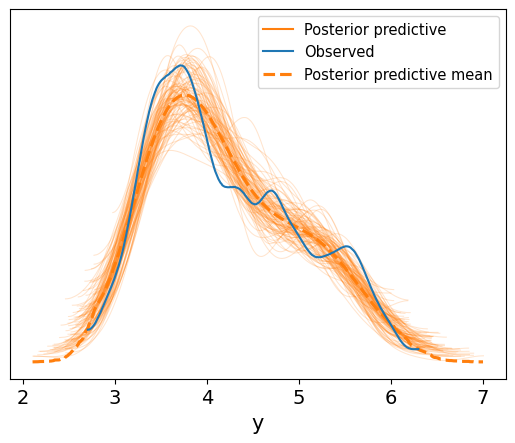

In [14]:
az.plot_ppc(idata_pen, num_pp_samples=100, colors=["C1", "C0", "C1"])

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

In [15]:
posterior_mean = idata_pen.posterior["μ"]

μ_hdi = az.hdi(ary=idata_pen, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_pen, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


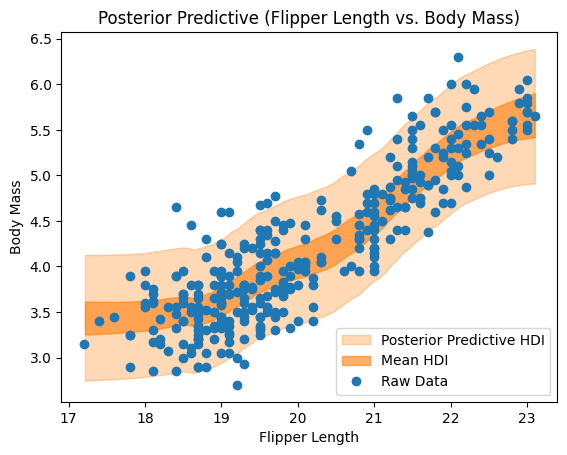

In [18]:
flipper_length_raw = penguins['flipper_length'].to_numpy()

# Sort flipper_length and get the indices
idx_sorted_flipper = np.argsort(flipper_length_raw)

# Apply sorting to flipper_length_data, pps, and posterior_mean
sorted_flipper_length = flipper_length_raw[idx_sorted_flipper]
sorted_pps = pps[:, idx_sorted_flipper]
sorted_posterior_mean = posterior_mean[:, :, idx_sorted_flipper]

fig, ax = plt.subplots()

az.plot_hdi(
    x=sorted_flipper_length,
    y=sorted_pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior Predictive HDI"},
)

az.plot_hdi(
    x=sorted_flipper_length,
    y=sorted_posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean HDI"},
)
ax.plot(penguins["flipper_length"], penguins["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive (Flipper Length vs. Body Mass)",
    xlabel="Flipper Length",
    ylabel="Body Mass",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

yes it looks really good. Mainly all the data points are in the orange.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='X_0'>, <Axes: xlabel='X_1'>, <Axes: xlabel='X_2'>],
      dtype=object)

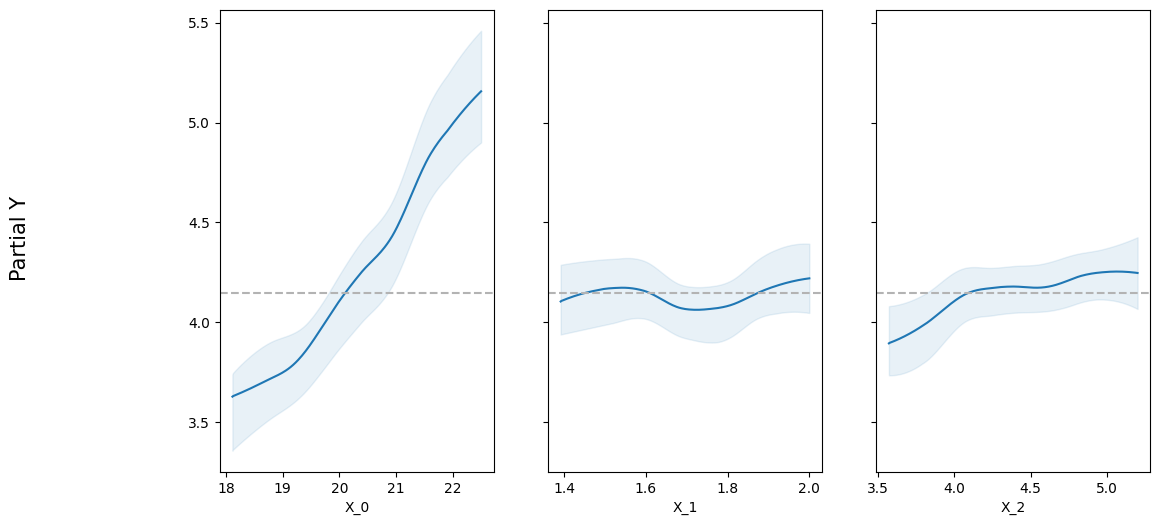

In [20]:
pmb.plot_pdp(μ_, X_bart, Y, grid=(1, 3), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='X_0'>, <Axes: xlabel='X_1'>, <Axes: xlabel='X_2'>],
      dtype=object)

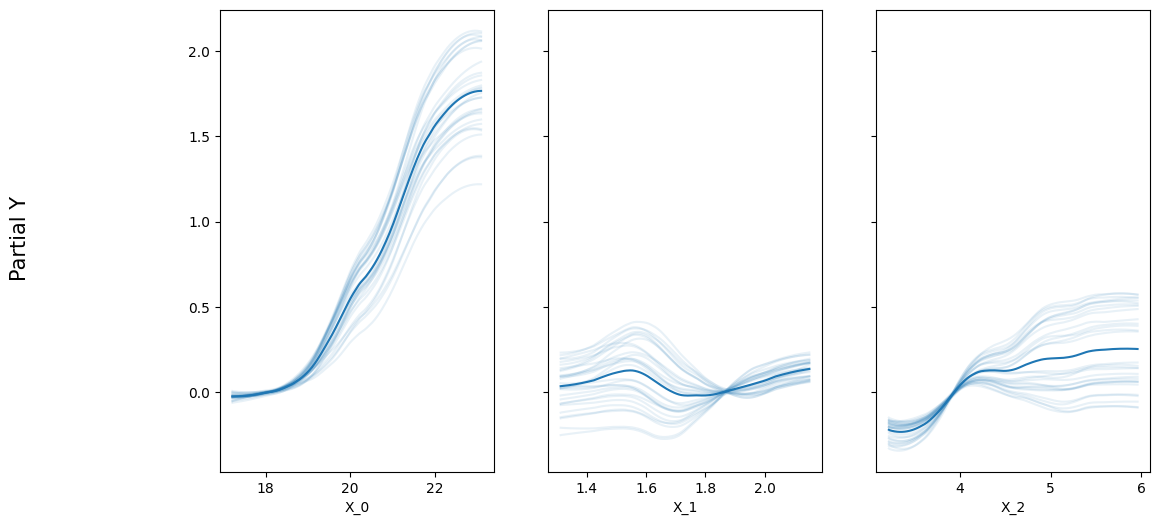

In [23]:
pmb.plot_ice(μ_, X_bart, Y, grid=(1, 3), func=np.exp, figsize = (12,6))

In [36]:
vi_penguins = pmb.compute_variable_importance(idata_pen, μ_, X_bart)

<Axes: ylabel='R²'>

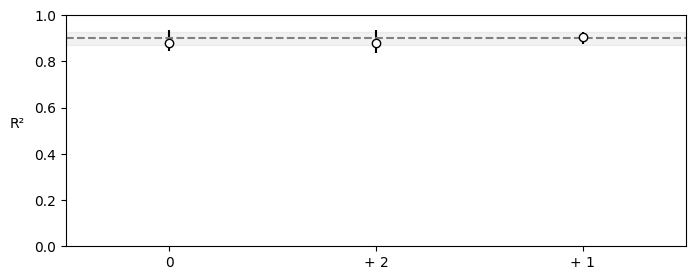

In [34]:
pmb.plot_variable_importance(vi_penguins)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

island or species.